# Progetto Data Analyst di Federico Critelli

Questo progetto si propone di analizzare un dataset di vini con l’obiettivo di fornire **insight pratici per un marketplace di vini**, individuando le migliori opportunità in termini di qualità-prezzo.

L’analisi si concentra su diversi aspetti chiave:  

- Identificare **i vini con il miglior rapporto qualità-prezzo** su scala globale, considerando prezzo e punteggio.  

- Esaminare la **distribuzione dei prezzi e dei punteggi**, individuando fasce economiche e fasce di qualità che offrono opportunità interessanti.  

- Analizzare i principali paesi produttori, con focus su **USA e Francia**, confrontando disponibilità, varietà e rapporto qualità-prezzo.  

- Evidenziare i **produttori emergenti e varietà di valore**, identificando bottiglie economiche ma apprezzate dai recensori.

In [32]:
#importo libreria pandas per la manipolazione e l'analisi dei dati
import pandas as pd

#importo libreria numpy per operazioni sugli array
import numpy as np

#importo matplotlib per creare grafici
import matplotlib.pyplot as plt

#importo seaborn perche offre grafici statistici piu avanzati e stilizzati rispetto a matplotlib
import seaborn as sns

#importo display e markdown utile per stampare descrizioni direttamente dalle celle di codice
from IPython.display import display, Markdown

#importo warnings perchè permette di gestire i warnings di Python
import warnings

In [33]:
#ignora tutti i warning
warnings.filterwarnings("ignore")

In [34]:
#importo il dataset in un dataframe
df_raw = pd.read_csv("winemag-data-130k-v2.csv")

### Inizio la mia analisi con delle prime indagini esplorative  del DataFrame 

In [35]:
def info_plus(df):
    """
    Restituisce un DataFrame con informazioni dettagliate sulle colonne del DataFrame originale.

    Parameters:

    df : pd.DataFrame
        Il DataFrame da analizzare.

    Returns:

    pd.DataFrame
        Un DataFrame contenente, per ogni colonna:
        - 'Column': il nome della colonna
        - 'Non-Null Count': il numero di valori non nulli
        - 'Null Count': il numero di valori nulli
        - '% Null': la percentuale di valori nulli (arrotondata a 2 decimali)
        - 'Dtype': il tipo di dati della colonna
    """

    #creo df reassuntivo delle info colonne
    info_df = pd.DataFrame({
        
        #nome di ogni colonna
        "Column": df.columns,
        
        #conto valori non nulli
        "Non-Null Count": df.notnull().sum().values,
        
        #conto valori  nulli
        "Null Count": df.isnull().sum().values,
       
       #calcola percentuale di valori nulli
        "% Null": (df.isnull().mean() * 100).round(2).values,
        
        #mostra tipo di dati per ogni colonna
        "Dtype": df.dtypes.values
    })
    
    #restituisce il df riassuntivo
    return info_df

#richiama la funzione
info_plus(df_raw)

,Column,Non-Null Count,Null Count,% Null,Dtype
0,Unnamed: 0,129971,0,0.00,int64
1,country,129908,63,0.05,object
2,description,129971,0,0.00,object
3,designation,92506,37465,28.83,object
4,points,129971,0,0.00,int64
5,price,120975,8996,6.92,float64
6,province,129908,63,0.05,object
7,region_1,108724,21247,16.35,object
8,region_2,50511,79460,61.14,object
9,taster_name,103727,26244,20.19,object


### Descrizione delle colonne

- unnamed: 0 = colonna contenente indici
- country = colonna contenente il nome del paese da cui proviene il vino
- description = colonna contenente la descrizione del vino
- designation = contenente il vigneto all'interno della cantina da cui provengono le uve che hanno prodotto il vino
- points = contenente il punteggio attribuito al vino
- price = contenente il costo di una bottiglia di vino
- province = contenente la provincia o lo stato da cui proviene il vino
- region_1 = contenente l'area di coltivazione della vite in una provincia o stato
- region_2 = contenente regioni più specifiche specificate all' interno di un' area vinicola
- taster_name = contenente il nome del sommelier che ha degustato il vino
- taster_twitter_handle	= contenente l'indirizzo twitter del sommelier
- title = contenente il titolo della recensione del vino, spesso contenente l'annata
- variety = contenente il tipo di uva utilizzata per produrre il vino
- winery = contenente la cantina che ha prodotto il vino

Dalla tabella soprastante si possono già notare le colonne contenenti dei valori nulli, la loro percentuale di presenza e il tipo di dato contenuto in ogni colonna.

In [36]:
#visualizzo le statistiche descrittive delle variabili numeriche
df_raw.describe()

,Unnamed: 0,points,price
count,129971.000000,129971.000000,120975.000000
mean,64985.000000,88.447138,35.363389
std,37519.540256,3.039730,41.022218
min,0.000000,80.000000,4.000000
25%,32492.500000,86.000000,17.000000
50%,64985.000000,88.000000,25.000000
75%,97477.500000,91.000000,42.000000
max,129970.000000,100.000000,3300.000000


Da questa visualizzazione delle statistiche descrittive, per quanto riguarda la colonna "points", si può notare che i valori minimo e massimo non sono molto distanti tra loro e che media e mediana coincidono. Questo fa pensare che potremmo trovarci di fronte a una distribuzione normale.

Al contrario, per quanto riguarda la colonna "price", i valori minimo e massimo appaiono molto distanti sia tra loro sia dalla media. Questo fa pensare alla presenza di diversi outlier.

Per questo motivo, decido di rappresentare i dati con un grafico, così da poterli comprendere meglio.

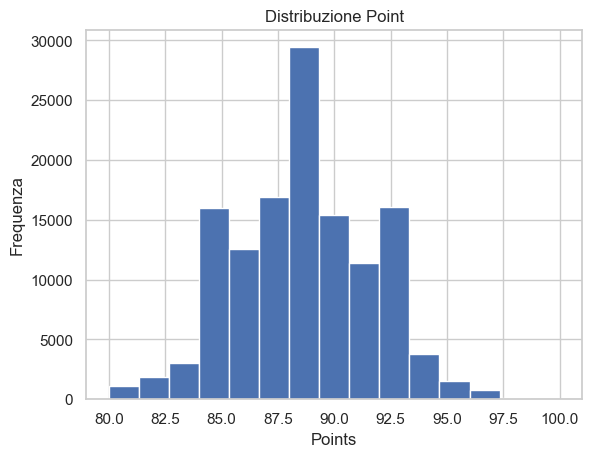

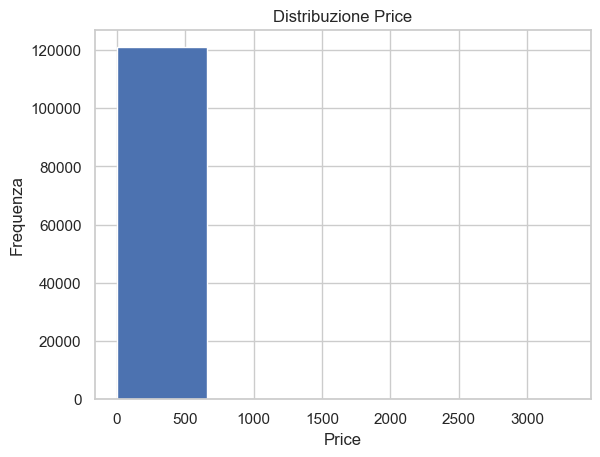

In [37]:
#creo istogramma della colonna "points"
df_raw['points'].hist(bins=15)

#titolo del grafico
plt.title('Distribuzione Point')

#etichetta asse "x"
plt.xlabel('Points')

#etichetta asse "y"
plt.ylabel('Frequenza')

#mostro il grafico
plt.show()

#creo istogramma della colonna "price"
df_raw['price'].hist(bins=5)

#titolo del grafico
plt.title('Distribuzione Price')

#etichetta asse "x"
plt.xlabel('Price')

#etichetta asse "y"
plt.ylabel('Frequenza')

#mostro il grafico
plt.show()

## Data Cleaning

Dopo questa prima fase esplorativa, decido di iniziare con il data cleaning così da poter eliminare le colonne che non sono utili per la mia analisi, rimuovere le righe contenenti valori "NaN" e verificare la presenza di eventuali valori anomali.

### Elimino colonne non utili alla mia analisi

In [38]:
# creo una copia del df
df = df_raw.copy()

#lista colonne non utili per la mia analisi
col_to_drop = ["Unnamed: 0", "description", "designation", "province", "region_1", "region_2", "taster_name", "taster_twitter_handle", "title" ]

#elimino colonne non utili alla mia analisi
df.drop(columns=col_to_drop, inplace=True)

#verifico che siano rimaste solo le colonne che desidero
df.columns

Index(['country', 'points', 'price', 'variety', 'winery'], dtype='object')

### Elimino righe contenenti valori 'NaN' 

In [39]:
#elimino righe con valori nulli nella colonna 'price', sapendo che i valori 'nan' corrispondono solamente al 6.92% dei valori presenti 
df.dropna(subset = "price", inplace = True)

#elimino l'unica righa con valore 'nan' presente nella colonna 'variety'
df.dropna(subset = "variety", inplace = True)

#elimino righe con valori 'nan' nella colonna 'country', corrispondendo solamente allo 0.05 non creano uno squilibrio nel dataframe 
df.dropna(subset = "country", inplace = True)


### Elimino outlier per ottenere una distribuzione più regolare

In [ ]:

#calcolo primo quantile
Q1 = df["price"].quantile(0.25)

#calcolo terzo quantile
Q3 = df["price"].quantile(0.75)

#calcolo differenza tra q3 e q1
IQR = Q3 - Q1

#definisco limite inferiore per identificare gli outlier
lower_bound = Q1 - 1.5 * IQR

#definisco limite superiore per identificare gli outlier
upper_bound = Q3 + 1.5 * IQR

#salvo il numero di righe del dataframe originale
original_rows = df.shape[0]

#creo un nuovo df contenente gli outlier eliminati per successive analisi
df_outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]

#sovrascrivo il dataframe filtrando gli outlier
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

#stampo il numero di righe rimanenti dopo il filtraggio 
print(f"Dimensione dopo rimozione outlier: {df.shape[0]} righe")

#stampo il numero di outlier eliminati dopo il filtraggio
print(f"Numero di outlier eliminati: {original_rows - df.shape[0]}")

Dimensione dopo rimozione outlier: 113674 righe
Numero di outlier eliminati: 7241


# Analisi del Dataset

### 10 bottiglie esclusive

In questa prima parte di analisi decido di esaminare più attentamente gli outlier eliminati, così da poter mostrare le 10 bottiglie più costose presenti nel DataFrame. Queste bottiglie potranno fornire insight utili per un eventuale assortimento di vini di alto pregio o da collezione, in un ipotetico marketplace di vino.

In [41]:
#seleziono le dieci bottiglie più costese e le ordino in maniera decrescente per prezzo
most_expensive = df_outliers.sort_values(by='price', ascending=False).head(10)

#resetto l'indice del df
most_expensive = most_expensive.reset_index(drop=True)

#modifico l'indice in modo che parta da 1 e non da 0
most_expensive.index = most_expensive.index + 1

#mostro il df con il nuovo indice
display(most_expensive)

,country,points,price,variety,winery
1,France,88,3300.0,Bordeaux-style Red Blend,Château les Ormes Sorbet
2,France,96,2500.0,Bordeaux-style Red Blend,Château Pétrus
3,France,96,2500.0,Pinot Noir,Domaine du Comte Liger-Belair
4,US,91,2013.0,Chardonnay,Blair
5,France,96,2000.0,Pinot Noir,Domaine du Comte Liger-Belair
6,France,97,2000.0,Bordeaux-style Red Blend,Château Pétrus
7,France,98,1900.0,Bordeaux-style Red Blend,Château Margaux
8,France,100,1500.0,Bordeaux-style Red Blend,Château Cheval Blanc
9,France,100,1500.0,Bordeaux-style Red Blend,Château Lafite Rothschild
10,France,96,1300.0,Bordeaux-style Red Blend,Château Mouton Rothschild


Se osserviamo il primo vino, cioè il vino più costoso del DataFrame, notiamo che il punteggio è perfettamente in linea con la media (che, come visto nell'analisi precedente, è proprio 88) mentre il prezzo è notevolmente superiore. Possiamo quindi dedurre che il prezzo non sia sempre un indicatore assoluto di qualità, ma possa essere influenzato da diverse cause, come motivi collezionistici, provenienza da cantine famose, annate rare o produzioni limitate.  

Inoltre, possiamo notare che il dataset che contiene le 10 bottiglie più costose è dominato da bottiglie francesi; per questo motivo, appare utile fare un’ulteriore analisi per individuare i 5 Paesi che dominano il dataset in termini di quantità di prodotti presenti, per capire se tra questi si annoveri anche la Francia stessa.

In [42]:
#conto quanti vini ci sono per ogni paese, ordino dal più grande al piu piccolo ed estraggo solamente i primi cinque
#riesco a capire quali sono i primi cinque paesi che detengono la maggior parte dei vini presenti nel dataframe ed estraggo la lista
top5 = df.groupby("country")["points"].count().sort_values(ascending = False).head().index

#filtra il df per i primi 5 paesi
df_top5 = df[df["country"].isin(top5)]

#ciclo for per mostrare paesi top 5
for c in top5:
    print(c)


US
France
Italy
Spain
Portugal


Come si può notare dalla lista soprastante che contiene i 5 Paesi che dominano il dataset, la Francia e gli USA, oltre a detenere le bottiglie più rare e costose del DataFrame, rientrano anche tra i cinque paesi con il maggior numero di bottiglie presenti nel DataFrame.  

Per questo motivo, appare ora utile confrontare la Francia e gli USA - i Paesi più presenti nel DataFrame - nel primo quantile dei prezzi, così da individuare le bottiglie che potrebbero suscitare interesse grazie a un buon rapporto qualità/prezzo.

### Statistiche dei prezzi dei vini di fascia bassa (Francia vs US)

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
France,4378.0,17.967337,8.913905,5.0,12.0,15.0,20.0,75.0
US,13927.0,24.022618,12.336397,4.0,15.0,20.0,30.0,79.0


### Statistiche dei punteggi dei vini di fascia bassa (Francia vs US)

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
France,4378.0,84.965509,1.081740,80.0,84.0,85.0,86.0,86.0
US,13927.0,84.605443,1.435154,80.0,84.0,85.0,86.0,86.0


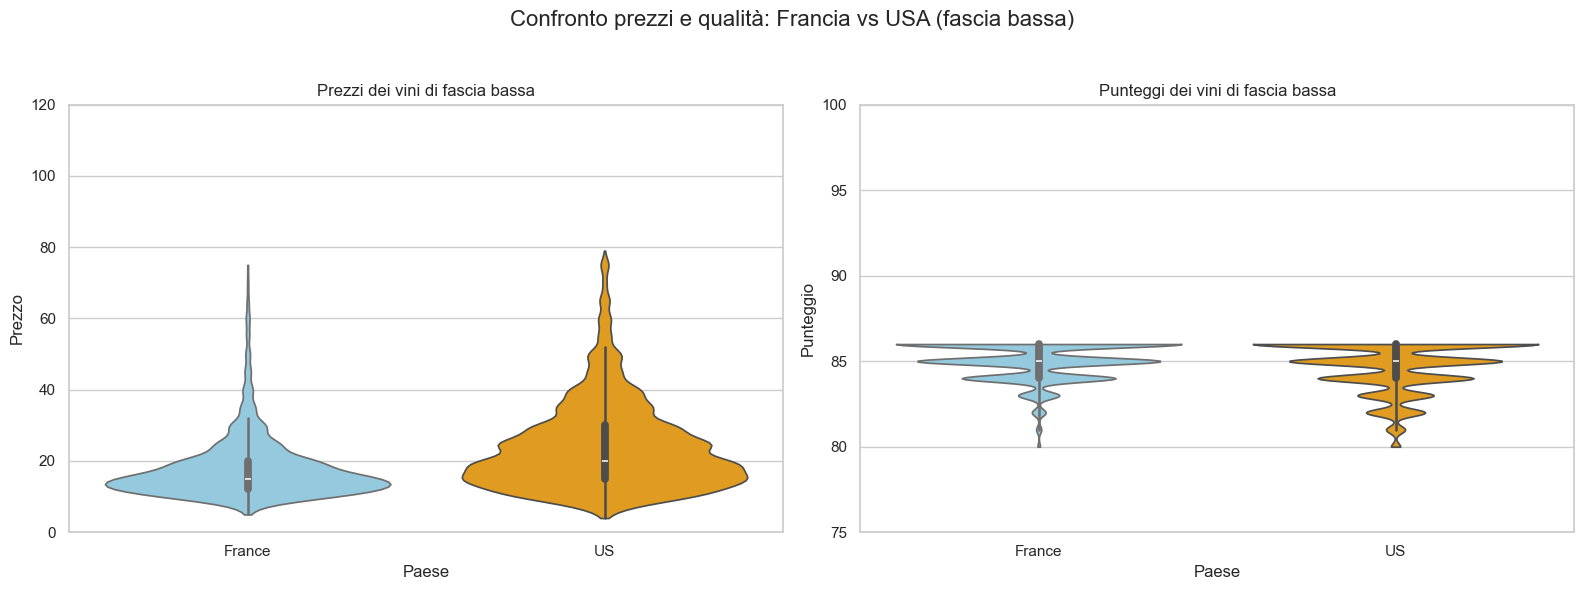

In [47]:
#filtro il df per Francia e US
df_fr_us = df[df["country"].isin(["France", "US"])]

#calcolo il 25° percentile per Francia e US
q1_points = df_fr_us.groupby("country")["points"].quantile(0.25)

#filtro i vini che rientrano nel 25° percentile
df_low_quality = df_fr_us[((df_fr_us["country"] == "France") & (df_fr_us["points"] <= q1_points["France"])) 
                          |((df_fr_us["country"] == "US") & (df_fr_us["points"] <= q1_points["US"]))]

#calcolo statistiche dei prezzi dei vini nella fascia bassa raggruppando per paese
price_stats = df_low_quality.groupby("country")["price"].describe()

#mostro titolo markdown per la tabella
display(Markdown("### Statistiche dei prezzi dei vini di fascia bassa (Francia vs US)"))

#visualizzo tabella prezzi
display(price_stats)


# Calcolo statistiche dei punteggi dei vini nella fascia bassa raggruppando per paese
points_stats = df_low_quality.groupby("country")["points"].describe()

#mostro titolo markdown per la tabella
display(Markdown("### Statistiche dei punteggi dei vini di fascia bassa (Francia vs US)"))

#visualizzo tabella punteggi
display(points_stats)

#imposto stile grafico di Seaborn
sns.set(style="whitegrid")

#creo figura con due grafici affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))


#creo violinplot dei prezzi per la Francia
sns.violinplot(

    #filtro per Francia
    data=df_low_quality[df_low_quality["country"]=="France"],
    x="country",
    y="price",

    #assegno colore alla Francia
    color="skyblue",
    
    #inserisco mini boxplot interno per mostare mediana e quantili
    inner="box",
    
    #evita che il grafico superi i valori reali
    cut=0,
    
    #assegno il grafico al primo asse
    ax=ax1
)

#creo violinplot dei prezzi per US
sns.violinplot(

    #filtro per US
    data=df_low_quality[df_low_quality["country"]=="US"],
    x="country",
    y="price",

    #assegno colore agli US
    color="orange",
    inner="box",
    cut=0,
    ax=ax1
)

#imposto titolo del primo grafico
ax1.set_title("Prezzi dei vini di fascia bassa")

#etichetta asse 'x'
ax1.set_xlabel("Paese")

#etichetta asse 'y'
ax1.set_ylabel("Prezzo")

#limito asse 'y' per rendere più leggibile la distribuzione principale
ax1.set_ylim(0, 120)


#creo violinplot dei punteggi per la Francia
sns.violinplot(
    data=df_low_quality[df_low_quality["country"]=="France"],
    x="country",
    y="points",
    color="skyblue",
    inner="box",
    cut=0,
    ax=ax2
)

#creo violinplot dei punteggi per gli US sullo stesso asse
sns.violinplot(
    data=df_low_quality[df_low_quality["country"]=="US"],
    x="country",
    y="points",
    color="orange",
    inner="box",
    cut=0,
    ax=ax2
)

#titolo del grafico
ax2.set_title("Punteggi dei vini di fascia bassa")

#etichetta asse 'x'
ax2.set_xlabel("Paese")

#etichetta asse 'y'
ax2.set_ylabel("Punteggio")

#limito asse 'y' per evidenziare meglio le differenze nei quantili
ax2.set_ylim(75, 100)

#aggiungo un titolo generale
plt.suptitle("Confronto prezzi e qualità: Francia vs USA (fascia bassa)", fontsize=16)

#ottimizzo la disposizione degli elementi per evitare sovrapposizioni
plt.tight_layout(rect=[0, 0, 1, 0.95])

#mostro grafico finale
plt.show()


Come possiamo osservare, sia i vini USA che quelli francesi nel primo quantile hanno un punteggio leggermente sotto la media dell'intero DataFrame, ma entrambe le categorie risultano molto vicine in termini di qualità. 

Possiamo notare inoltre che gli USA hanno una maggiore disponibilità di bottiglie; mentre - in termini di prezzo -  i vini francesi si attestano come leggermente meno costosi rispetto a quelli USA.  

In conclusione, questi dati ci permettono di fornire insight utili per un ipotetico marketplace di vini: i vini francesi risultano infatti equivalenti ai vini USA in termini di qualità, ma offrono prezzi leggermente più competitivi, almeno se consideriamo il primo quantile dei prezzi.

## 10 Bottiglie più competitive per rapporto qualità/prezzo
Una volta fatto il confronto Francia/USA, decido di prendere in esame il -primo quartile dei prezzi globali- e mostrare le dieci bottiglie più convenienti nel DataFrame in termini di rapporto qualità/prezzo.

In [48]:
#Calcolo del primo quantile (25° percentile) dei prezzi globali
q1_price = df["price"].quantile(0.25)

#Seleziono i vini con prezzo minore o uguale al primo quantile
low_price_wines = df[df["price"] <= q1_price]

#Ordino questi vini per punteggio decrescente
best_low_price_wines = low_price_wines.sort_values(by="points", ascending=False)

#Seleziono solo le colonne desiderate e prendo i primi 10
best_low_price_wines = best_low_price_wines[["country", "variety","winery", "price", "points"]].head(10)

#Resetto l'indice per farlo partire da 1
best_low_price_wines = best_low_price_wines.reset_index(drop=True)
best_low_price_wines.index = best_low_price_wines.index + 1

#Titolo Markdown per la tabella
display(Markdown("### Top 10 vini -1° quartile- con punteggi più alti"))

#Mostro la tabella finale
display(best_low_price_wines)

### Top 10 vini -1° quartile- con punteggi più alti

,country,variety,winery,price,points
1,Spain,Sherry,Osborne,14.0,94
2,US,Moscato Giallo,Uvaggio,16.0,94
3,Portugal,Portuguese Red,Quinta dos Murças,13.0,94
4,US,Viognier,Novy,14.0,93
5,US,Pinot Gris,David Hill,16.0,93
6,Austria,Grüner Veltliner,Allram,14.0,93
7,Portugal,Portuguese Red,Companhia das Quintas,16.0,93
8,US,Viognier,Novy,14.0,93
9,South Africa,Cabernet Sauvignon,Simonsig,15.0,93
10,France,Malbec-Merlot,Château Vincens,13.0,93


Dalla tabella soprastante possiamo osservare 10 bottiglie che rappresentano le eccezioni nel DataFrame, appartenenti al primo quartile dei prezzi ma con punteggi ben al di sopra della media.  

Questi vini mostrano opportunità d'affare imperdibili, combinando qualità elevata e prezzo contenuto.

## Distribuzione dei prezzi per fascia di punteggio

Decido ora di analizzare la distribuzione dei prezzi sull'intero DataFrame, così da poter fornire insight chiave riguardanti la relazione tra prezzo e fascia di punteggio dei vini.

,count,mean,std,min,25%,50%,75%,max
score_range,,,,,,,,
80-85,20633.0,18.853875,10.629768,4.0,12.0,15.0,23.0,79.0
86-90,67507.0,26.956879,14.046940,4.0,16.0,23.0,35.0,79.0
91-95,25297.0,42.972092,16.032046,7.0,30.0,42.0,55.0,79.0
96-100,237.0,58.624473,13.353026,20.0,50.0,60.0,70.0,79.0


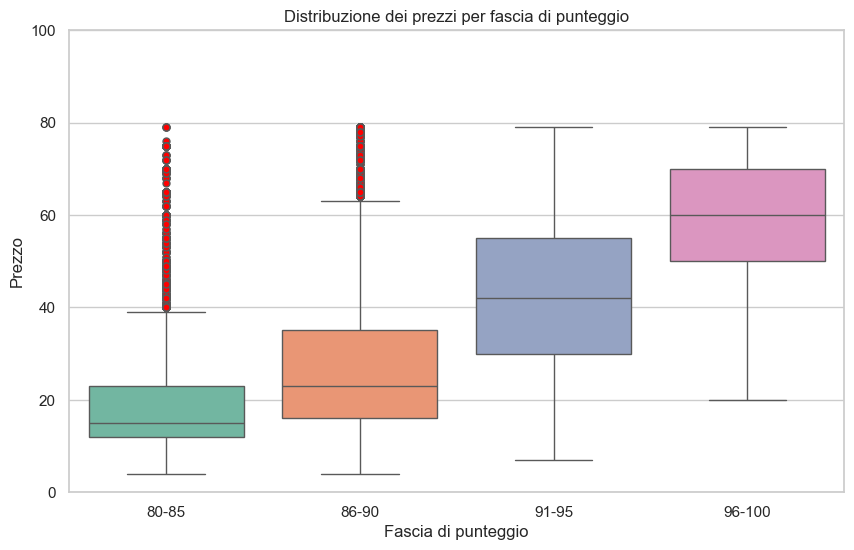

In [45]:
#definisco i limiti delle fasce di punteggio
bins = [0, 85, 90, 95, 100]

#definisco le etichette corrispondenti a ciascuna fascia
labels = ["80-85", "86-90", "91-95", "96-100"]

#Creo una colonna  che divide i vini in fasce di punteggio definite dai bin
df["score_range"] = pd.cut(df["points"], bins=bins, labels=labels, right=True)

#raggruppo i vini per fascia di punteggio e calcolo statistiche descrittive dei prezzi
price_score = df.groupby("score_range", observed=True)["price"].describe()

#mostro tabella
display(price_score)

#imposto la dimensione del grafico
plt.figure(figsize=(10,6))

#creo un boxplot dei prezzi per ciascuna fascia di punteggio
sns.boxplot(
    x="score_range",
    y="price",
    data=df,
    palette="Set2",
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)

#imposto la dimensione della figura
plt.title("Distribuzione dei prezzi per fascia di punteggio")

#etichetta asse 'x'
plt.xlabel("Fascia di punteggio")

#etichetta asse 'y'
plt.ylabel("Prezzo")

#limito l'asse 'y' per evidenziare meglio la maggior parte dei prezzi
plt.ylim(0, 100)  

#mostro il grafico
plt.show()

Considerando che l'obiettivo è quello di individuare bottiglie con un punteggio medio-alto ma acquistabili a prezzi contenuti e competitivi, dal grafico soprastante è possibile notare come buona parte delle bottiglie con un punteggio superiore alla media (fascia 91-95) risulti acquistabile a un prezzo inferiore ai 40 euro, rappresentando un'ottima opportunità d'affare.

Se esaminiamo le fasce di punteggio più basse (80-85 e 86-90), si osserva come la maggior parte dei prezzi resti concentrata in una fascia relativamente economica, ma con alcuni outlier che si allontanano dalla media: queste bottiglie sono comunque da considerare, poiché potrebbero risultare interessanti per collezionisti e fini intenditori.

Osservando invece i vini di fascia più alta (punteggio 96-100), possiamo individuare alcune buone opportunità prendendo in considerazione bottiglie di alto pregio acquistabili a circa 50 euro, simboleggiando un'ottima offerta per i clienti più esigenti.

## Correlazione prezzo/punteggio
Dopo aver esaminato la distribuzione dei prezzi per punteggio decido di analizzare la correlazione tra le due variabili cosi da verificare davanti a quale tipo di relazione ci troviamo. 

correlazione (r): 0.5383061267708996


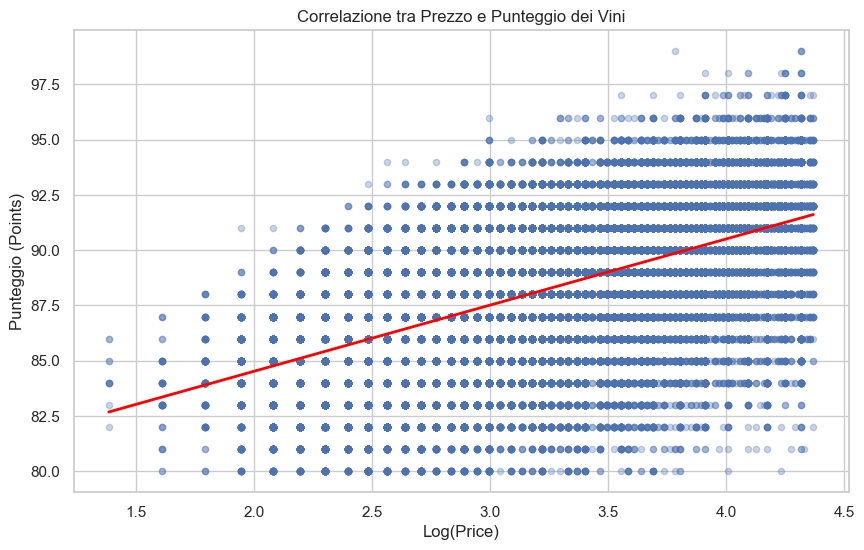

In [46]:
# Calcolo correlazione tra prezzo e punteggio
r = df["price"].corr(df["points"])

#stampo valore della correlazione
print(f"correlazione (r): {r}")

#creo la figura per il grafico
plt.figure(figsize=(10,6))

#Scatter plot con linea di regressione
sns.regplot(
    
    #logaritmo del prezzo per gestire distribuzione skewed
    x=np.log(df["price"]), 
    
    #punteggio dei vini
    y=df["points"],
    
    #punti semi-trasparenti
    scatter_kws={"alpha":0.3, "s":20}, 
    
    #linea di regressione
    line_kws={"color":"red", "linewidth":2}  
)
#etichetta asse 'x'
plt.xlabel("Log(Price)")

#etichetta asse 'y'
plt.ylabel("Punteggio (Points)")

#titolo del grafico
plt.title("Correlazione tra Prezzo e Punteggio dei Vini")

# aggiungo la griglia per facilitare la lettura
plt.grid(True)

#mostro il grafico
plt.show()

Dalle analisi soprastanti emerge che i dati precedenti vengono confermati, poiché la relazione tra prezzo e punteggio risulta positiva ma moderata (0.538).  

Questo suggerisce che, in generale, i prezzi tendono ad aumentare all'aumentare dei punteggi. Tuttavia, il risultato indica anche che il prezzo non è sempre fortemente correlato al punteggio e può essere influenzato da diversi fattori, permettendoci di individuare numerose eccezioni e confermando le osservazioni fatte nelle analisi precedenti.

## Proposta di assortimento per un marketplace di vino

Per quanto riguarda l'assortimento di un ipotetico marketplace di vino, a fronte delle analisi condotte fino ad ora consiglierei di:

- Concentrarsi principalmente su bottiglie con un ottimo rapporto qualità/prezzo, che dovrebbero essere sempre presenti (v. top 10 vini del 1° quartile). Queste rappresenterebbero ottime opportunità per ogni tipo di clientela.  

- Prestare attenzione alle bottiglie con punteggio compreso tra 91 e 95, dove si concentrano gli affari nascosti, come mostrato nel grafico precedente (v. distribuzione dei prezzi per fascia di punteggio).  

- Inserire una quantità esigua di bottiglie che rappresentano outlier nel dataset (v. 10 bottiglie esclusive), in modo da suscitare la curiosità dei clienti più esigenti.  

- Non trascurare una piccola quantità di bottiglie di fascia bassa, con prezzi non proporzionati al punteggio, che potrebbero rappresentare una nicchia per appassionati e collezionisti.

- Acquistare bottiglie dai maggiori referenti sul mercato come ad esempio Francia ed USA, tenedo conto che la Francia sul primo quantile di prezzi resta economicamente più competitiva. (v. confronto prezzi e qualità: Francia vs USA)